# Multiwell: mpCN vs mTPCN (with pCN baseline)

This notebook is a minimal, end-to-end example for generating a multiwell dataset, running mpCN/mTPCN/pCN, and caching outputs under `estimations/`. It is written for new users and includes: data generation, cached runs, trace plots, posterior histograms, and an ESS/MSJD summary table.

We also estimate a reference `true` parameter by running MESS for 50k iterations and averaging after burn-in. That value is overlaid in the trace plots and histograms.

## 1) Setup and imports

We locate the repo root, add it to `sys.path`, and import the sampler implementations.

In [2]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root and add to sys.path
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_path = repo_root / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from multiproposal.algorithms.mpcn import mpcn_chain
from multiproposal.algorithms.mtpcn import mtpcn_chain
from multiproposal.algorithms.pcn import pcn_chain
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import (
    estimate_effective_sample_size,
    compute_mean_squared_jumping_distance,
)
from multiproposal.problems.toy_custom_likelihood import ToyCustomLikelihood2D
from multiproposal.utils.run_paths import build_run_dirs, format_float_tag
from reports.figure_style import apply_pub_style

## 2) Configure and generate data

Adjust the parameters below to generate a synthetic dataset from the 16-polynomic wells map.

In [3]:
def f_16polynomic_wells(x):
    x1, x2 = x
    comp1 = (x1 ** 2 - 1) * (x1 ** 2 - 4)
    comp2 = (x2 ** 2 - 1) * (x2 ** 2 - 4)
    return np.array([comp1, comp2])

def log_likelihood_16polynomic(x, y_obs, sigma):
    r = f_16polynomic_wells(x) - y_obs
    return -0.5 * np.dot(r, r) / (sigma ** 2)

# Data generation parameters (edit these)
sigma_noise = 1.0
prior_std = 1.0
data_seed = 202

prior_mean = np.zeros(2)
prior_cov = (prior_std ** 2) * np.eye(2)

rng_data = np.random.default_rng(data_seed)
x_true = rng_data.multivariate_normal(prior_mean, prior_cov)
theta_true = f_16polynomic_wells(x_true)
y_obs = theta_true + rng_data.normal(0.0, sigma_noise, size=theta_true.shape)

print('y_obs:', y_obs)
print('x_true (prior draw):', x_true)

y_obs: [-2.72358526  1.22300603]
x_true (prior draw): [ 1.81172035 -0.72905356]


## 3) Sampler settings

Enable/disable algorithms and set chain lengths here. We use the same data for all algorithms.

In [4]:
# Which algorithms to run
run_mpcn = True
run_mtpcn = True
run_pcn = True

# MCMC configuration
n_iters = 20000
burn_in = 2000
rho = 0.1
n_props = 20
seed_mcmc = 202

# MESS reference run (for 'true' value)
mess_iters = 50000
mess_burn_in = 5000
mess_M = 10

rng_mpcn = np.random.default_rng(seed_mcmc)
rng_mtpcn = np.random.default_rng(seed_mcmc + 1)
rng_pcn = np.random.default_rng(seed_mcmc + 2)
rng_mess = np.random.default_rng(seed_mcmc + 3)

# Start at stationarity (simple deterministic start for this toy example)
x0 = np.array([-1.5, -0.8], dtype=float)

## 4) Problem definition and run directories

We define the posterior and create run directories in `estimations/` and `reports/`. Outputs are cached and reused when present.

In [5]:
def log_likelihood(x):
    return log_likelihood_16polynomic(x, y_obs, sigma=sigma_noise)

problem = ToyCustomLikelihood2D(
    log_likelihood_fn=log_likelihood,
    prior_mean=prior_mean,
    prior_cov=prior_cov,
)

data_config = {
    "sigma_noise": sigma_noise,
    "prior_std": prior_std,
    "prior_cov": prior_cov.tolist(),
    "prior_mean": prior_mean.tolist(),
    "data_seed": data_seed,
}

algo_config = {
    "n_iters": n_iters,
    "burn_in": burn_in,
    "rho": rho,
    "n_props": n_props,
    "seed_mcmc": seed_mcmc,
    "x0": x0.tolist(),
    "mess_iters": mess_iters,
    "mess_burn_in": mess_burn_in,
    "mess_M": mess_M,
}

rho_tag = format_float_tag(rho)
sigma_tag = format_float_tag(sigma_noise)
prior_tag = format_float_tag(prior_std)
tag_parts = [
    f"P{n_props}",
    f"rho{rho_tag}",
    f"iters{n_iters}",
    f"seed{seed_mcmc}",
    f"sigma{sigma_tag}",
    f"prior{prior_tag}",
]

mpcn_estimations_dir, mpcn_reports_dir, _, _ = build_run_dirs(
    repo_root,
    dataset="multiwell",
    algorithm="mpcn",
    data_config=data_config,
    algorithm_config=algo_config,
    algorithm_dir="",
    tag_parts=tag_parts,
)
mtpcn_estimations_dir, mtpcn_reports_dir, _, _ = build_run_dirs(
    repo_root,
    dataset="multiwell",
    algorithm="mtpcn",
    data_config=data_config,
    algorithm_config=algo_config,
    algorithm_dir="",
    tag_parts=tag_parts,
)
pcn_estimations_dir, pcn_reports_dir, _, _ = build_run_dirs(
    repo_root,
    dataset="multiwell",
    algorithm="pcn",
    data_config=data_config,
    algorithm_config=algo_config,
    algorithm_dir="",
    tag_parts=[f"rho{rho_tag}", f"iters{n_iters}", f"seed{seed_mcmc}"],
)
mess_estimations_dir, mess_reports_dir, _, _ = build_run_dirs(
    repo_root,
    dataset="multiwell",
    algorithm="mess_truth",
    data_config=data_config,
    algorithm_config=algo_config,
    algorithm_dir="",
    tag_parts=[f"M{mess_M}", f"iters{mess_iters}", f"seed{seed_mcmc}"],
)

reports_dir = mpcn_reports_dir
reports_dir.mkdir(parents=True, exist_ok=True)

## 5) Cache helpers

We store each chain in the estimations folder and reload if present.

In [6]:
def save_chain_bundle(samples_path, chain, accept_rate, runtime_sec):
    accept_val = np.nan if accept_rate is None else float(accept_rate)
    np.savez_compressed(
        samples_path,
        chain=chain,
        accept_rate=accept_val,
        runtime_sec=float(runtime_sec),
    )


def load_chain_bundle(samples_path):
    if not samples_path.exists():
        return None
    data = np.load(samples_path, allow_pickle=False)
    chain = data["chain"]
    accept_rate = float(data["accept_rate"]) if "accept_rate" in data else np.nan
    if np.isnan(accept_rate):
        accept_rate = None
    runtime_sec = float(data["runtime_sec"]) if "runtime_sec" in data else 0.0
    return chain, accept_rate, runtime_sec

## 6) MESS reference run ("true" value)

We run MESS for 50k iterations (cached) and compute the posterior mean after burn-in.

In [7]:
mess_samples_path = (
    mess_estimations_dir
    / f"mess_truth_M{mess_M}_iters{mess_iters}_seed{seed_mcmc}.npz"
)
mess_loaded = load_chain_bundle(mess_samples_path)
if mess_loaded is not None:
    mess_chain, _, mess_runtime_sec = mess_loaded
    print(f"MESS loaded: runtime={mess_runtime_sec:.2f}s")
else:
    mess_chain = np.zeros((mess_iters + 1, problem.dim), dtype=float)
    mess_chain[0] = x0
    x = x0.copy()
    t0 = time.perf_counter()
    for t in range(mess_iters):
        x, _, _ = mess_step(
            x,
            problem,
            rng_mess,
            M=mess_M,
            use_lp=False,
            distance_metric="angular",
            lam=0.0,
        )
        mess_chain[t + 1] = x
    mess_runtime_sec = time.perf_counter() - t0
    save_chain_bundle(mess_samples_path, mess_chain, None, mess_runtime_sec)
    print(f"MESS done: runtime={mess_runtime_sec:.2f}s")

true_mean = np.mean(mess_chain[mess_burn_in:], axis=0)
print("true_mean from MESS:", true_mean)

MESS done: runtime=1.75s
true_mean from MESS: [-0.00022548  0.00207899]


## 7) Run mpCN, mTPCN, and pCN (cached)

Each algorithm is saved under its own estimations directory.

In [8]:
apply_pub_style()

mpcn_samples_path = (
    mpcn_estimations_dir / f"mpcn_P{n_props}_rho{rho_tag}_seed{seed_mcmc}.npz"
)
mtpcn_samples_path = (
    mtpcn_estimations_dir / f"mtpcn_P{n_props}_rho{rho_tag}_seed{seed_mcmc}.npz"
)
pcn_samples_path = pcn_estimations_dir / f"pcn_rho{rho_tag}_seed{seed_mcmc}.npz"

chain_mpcn = None
runtime_mpcn_sec = 0.0
if run_mpcn:
    mpcn_loaded = load_chain_bundle(mpcn_samples_path)
    if mpcn_loaded is not None:
        chain_mpcn, accept_rate_mpcn, runtime_mpcn_sec = mpcn_loaded
        print(f"mpCN loaded: runtime={runtime_mpcn_sec:.2f}s, accept={accept_rate_mpcn}")
    else:
        t0 = time.perf_counter()
        chain_mpcn, accepted_index = mpcn_chain(
            x0,
            problem,
            rng_mpcn,
            n_iters,
            rho=rho,
            n_props=n_props,
            return_indices=True,
        )
        runtime_mpcn_sec = time.perf_counter() - t0
        accept_rate_mpcn = float(np.mean(accepted_index != 0))
        save_chain_bundle(mpcn_samples_path, chain_mpcn, accept_rate_mpcn, runtime_mpcn_sec)
        print(f"mpCN done: runtime={runtime_mpcn_sec:.2f}s, accept={accept_rate_mpcn:.3f}")

chain_mtpcn = None
runtime_mtpcn_sec = 0.0
if run_mtpcn:
    mtpcn_loaded = load_chain_bundle(mtpcn_samples_path)
    if mtpcn_loaded is not None:
        chain_mtpcn, accept_rate_mtpcn, runtime_mtpcn_sec = mtpcn_loaded
        print(f"mTPCN loaded: runtime={runtime_mtpcn_sec:.2f}s, accept={accept_rate_mtpcn}")
    else:
        t0 = time.perf_counter()
        chain_mtpcn, accept_rate_mtpcn = mtpcn_chain(
            x0,
            problem,
            rng_mtpcn,
            n_iters,
            rho=rho,
            n_props=n_props,
        )
        runtime_mtpcn_sec = time.perf_counter() - t0
        save_chain_bundle(mtpcn_samples_path, chain_mtpcn, accept_rate_mtpcn, runtime_mtpcn_sec)
        print(f"mTPCN done: runtime={runtime_mtpcn_sec:.2f}s, accept={accept_rate_mtpcn:.3f}")

chain_pcn = None
runtime_pcn_sec = 0.0
if run_pcn:
    pcn_loaded = load_chain_bundle(pcn_samples_path)
    if pcn_loaded is not None:
        chain_pcn, accept_rate_pcn, runtime_pcn_sec = pcn_loaded
        print(f"pCN loaded: runtime={runtime_pcn_sec:.2f}s, accept={accept_rate_pcn}")
    else:
        t0 = time.perf_counter()
        chain_pcn, accept_rate_pcn = pcn_chain(
            x0,
            problem,
            rng_pcn,
            n_iters,
            rho=rho,
            return_acceptance=True,
        )
        runtime_pcn_sec = time.perf_counter() - t0
        save_chain_bundle(pcn_samples_path, chain_pcn, accept_rate_pcn, runtime_pcn_sec)
        print(f"pCN done: runtime={runtime_pcn_sec:.2f}s, accept={accept_rate_pcn:.3f}")

mpCN done: runtime=0.96s, accept=0.565
mTPCN done: runtime=1.78s, accept=0.585
pCN done: runtime=0.13s, accept=0.081


## 8) Trace plots

Trace plots use a fixed 30,000-iteration window after burn-in (or fewer if the chain is shorter). The MESS-based `true_mean` is shown as a dashed line.

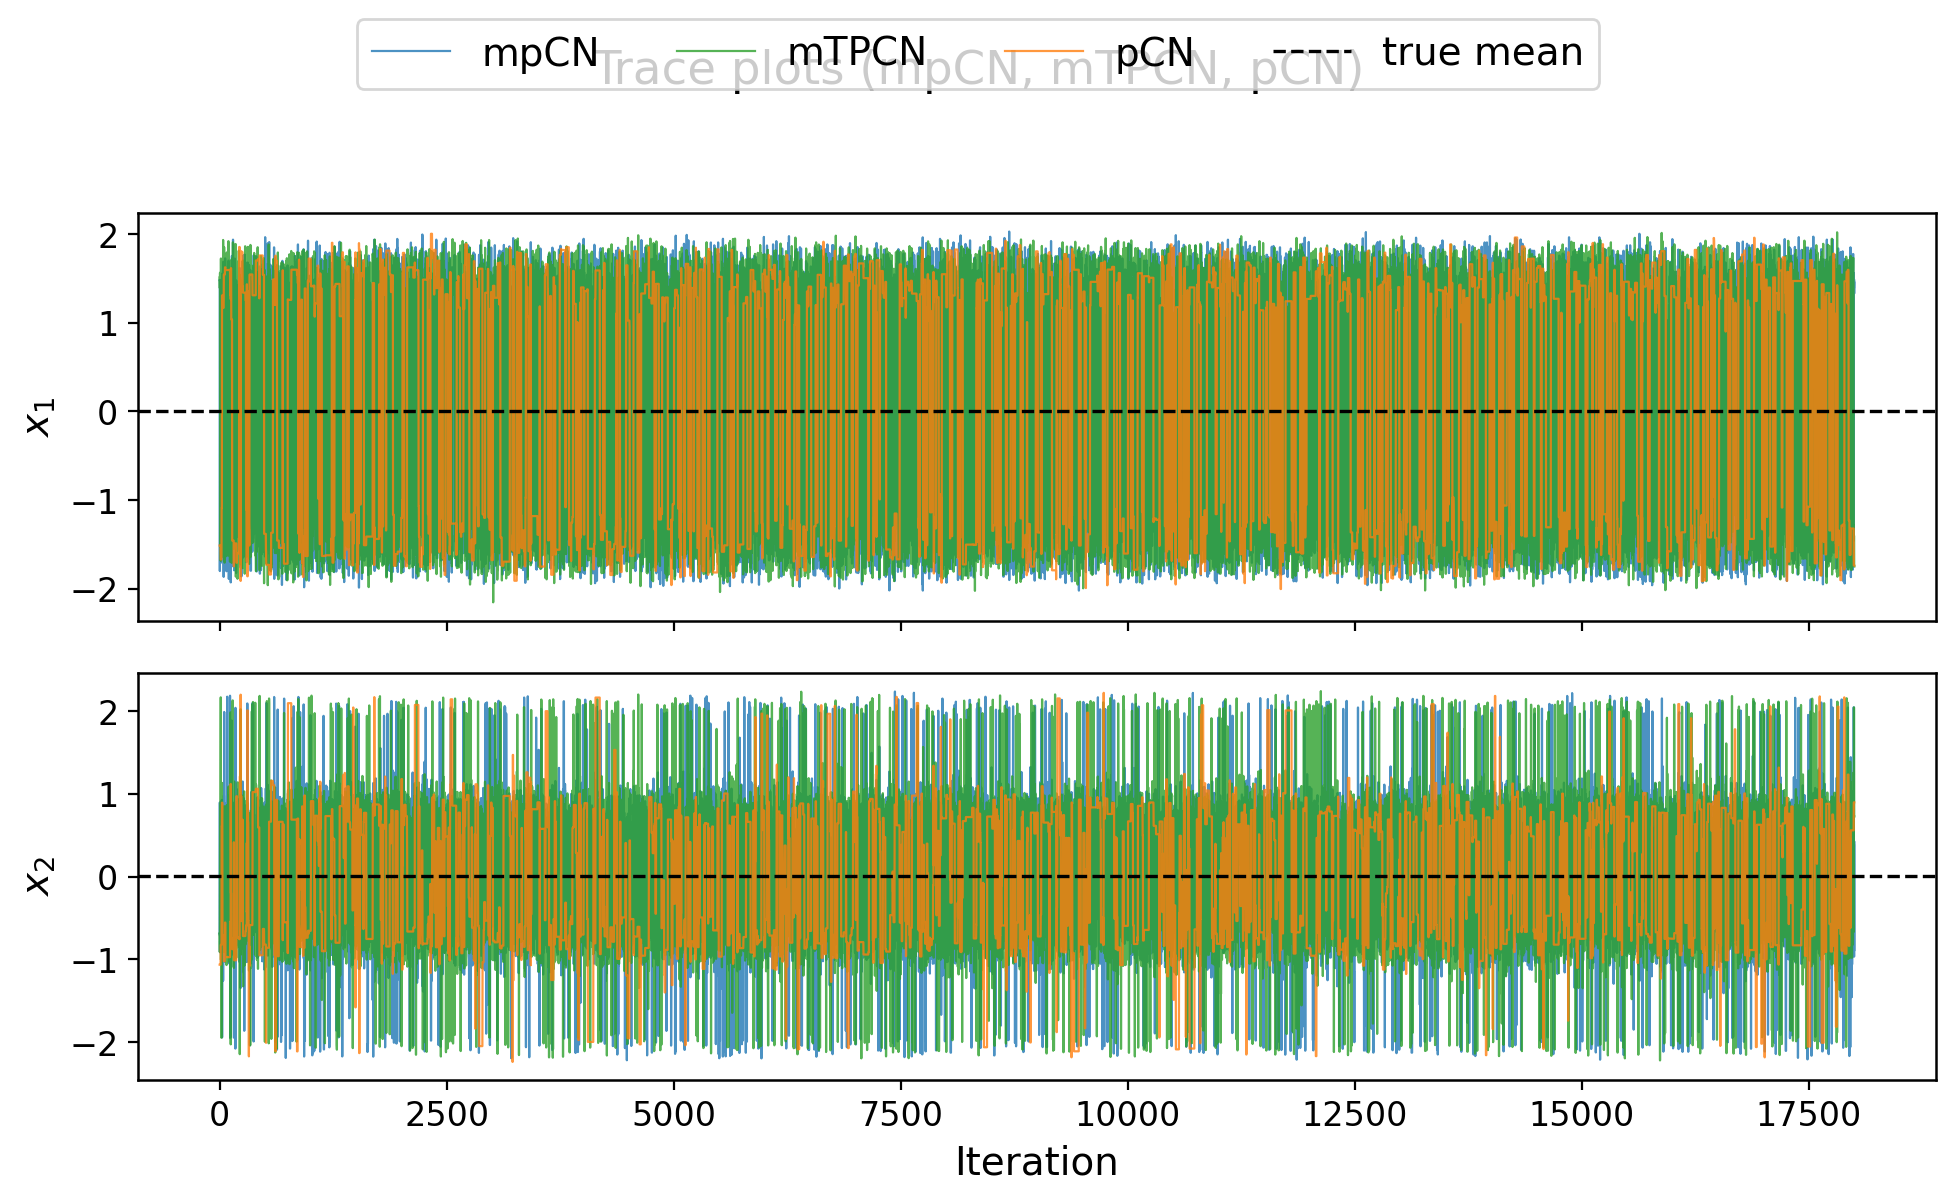

Saved trace plots to: /home/senng/multiproposal-internal/reports/multiwell/multiwell_mpcn_P20_rho0p10000_iters20000_seed202_sigma1p00000_prior1p00000_h9b77a760deed/traceplots_multiwell_P20_rho0p10000.png


In [9]:
def window_chain(chain, burn_in, window_len=30000):
    if chain is None:
        return None
    start = min(burn_in, len(chain) - 1)
    end = min(len(chain), start + window_len)
    return chain[start:end]

plot_chains = {
    "mpCN": window_chain(chain_mpcn, burn_in),
    "mTPCN": window_chain(chain_mtpcn, burn_in),
    "pCN": window_chain(chain_pcn, burn_in),
}
plot_chains = {k: v for k, v in plot_chains.items() if v is not None}

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
colors = {"mpCN": "tab:blue", "mTPCN": "tab:green", "pCN": "tab:orange"}

for label, chain in plot_chains.items():
    axes[0].plot(chain[:, 0], color=colors.get(label, "black"), alpha=0.8, linewidth=0.8, label=label)
    axes[1].plot(chain[:, 1], color=colors.get(label, "black"), alpha=0.8, linewidth=0.8, label=label)

if true_mean is not None:
    axes[0].axhline(true_mean[0], color="black", linestyle="--", linewidth=1.2, label="true mean")
    axes[1].axhline(true_mean[1], color="black", linestyle="--", linewidth=1.2)

axes[0].set_ylabel(r"$x_1$")
axes[1].set_ylabel(r"$x_2$")
axes[1].set_xlabel("Iteration")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Trace plots (mpCN, mTPCN, pCN)")
fig.tight_layout(rect=(0, 0, 1, 0.95))
trace_path = reports_dir / f"traceplots_multiwell_P{n_props}_rho{rho_tag}.png"
fig.savefig(trace_path, bbox_inches="tight")
plt.show()
print(f"Saved trace plots to: {trace_path}")

## 9) Posterior histograms

Histograms show the posterior marginals for each coordinate. The dashed line is the MESS-based reference mean.

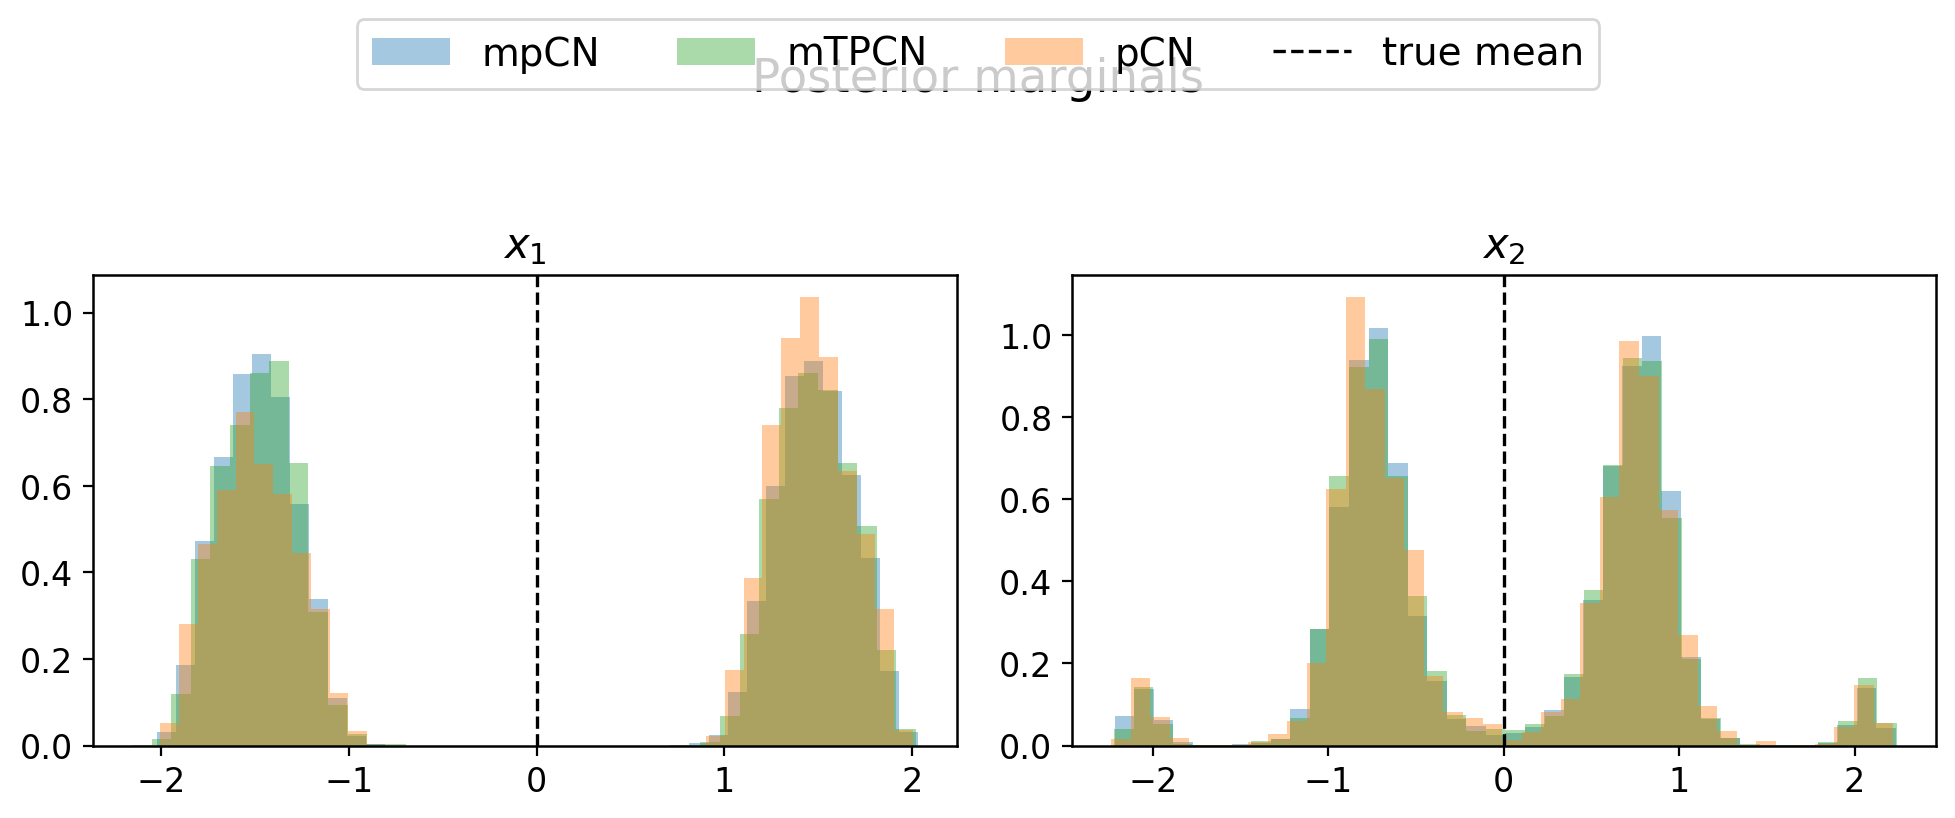

Saved histograms to: /home/senng/multiproposal-internal/reports/multiwell/multiwell_mpcn_P20_rho0p10000_iters20000_seed202_sigma1p00000_prior1p00000_h9b77a760deed/histograms_multiwell_P20_rho0p10000.png


In [10]:
post_chains = {
    "mpCN": chain_mpcn[burn_in:] if chain_mpcn is not None else None,
    "mTPCN": chain_mtpcn[burn_in:] if chain_mtpcn is not None else None,
    "pCN": chain_pcn[burn_in:] if chain_pcn is not None else None,
}
post_chains = {k: v for k, v in post_chains.items() if v is not None}

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
bins = 40

for label, chain in post_chains.items():
    axes[0].hist(chain[:, 0], bins=bins, density=True, alpha=0.4, label=label, color=colors.get(label, "black"))
    axes[1].hist(chain[:, 1], bins=bins, density=True, alpha=0.4, label=label, color=colors.get(label, "black"))

if true_mean is not None:
    axes[0].axvline(true_mean[0], color="black", linestyle="--", linewidth=1.2, label="true mean")
    axes[1].axvline(true_mean[1], color="black", linestyle="--", linewidth=1.2)

axes[0].set_title(r"$x_1$")
axes[1].set_title(r"$x_2$")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.05))
fig.suptitle("Posterior marginals")
fig.tight_layout(rect=(0, 0, 1, 0.93))
hist_path = reports_dir / f"histograms_multiwell_P{n_props}_rho{rho_tag}.png"
fig.savefig(hist_path, bbox_inches="tight")
plt.show()
print(f"Saved histograms to: {hist_path}")

## 10) ESS/MSJD summary table

We compute per-coordinate ESS and MSJD, plus ESS/sec and MSJD/sec using the recorded runtime.

In [11]:
def summarize_metrics(chain, runtime_sec, max_lag=500):
    post = chain[burn_in:]
    ess_vals = estimate_effective_sample_size(post, max_lag=max_lag)
    ess_vals = np.asarray(ess_vals, dtype=float)
    msjd_vals = compute_mean_squared_jumping_distance(post)
    msjd_vals = np.asarray(msjd_vals, dtype=float)
    runtime_sec = float(runtime_sec)
    ess_per_sec = ess_vals / runtime_sec if runtime_sec > 0 else np.full_like(ess_vals, np.nan)
    msjd_per_sec = msjd_vals / runtime_sec if runtime_sec > 0 else np.full_like(msjd_vals, np.nan)
    return ess_vals, msjd_vals, ess_per_sec, msjd_per_sec

rows = []

if chain_mpcn is not None:
    ess, msjd, ess_ps, msjd_ps = summarize_metrics(chain_mpcn, runtime_mpcn_sec)
    for idx in range(problem.dim):
        rows.append(
            {
                "algorithm": "mpCN",
                "coord": f"x{idx + 1}",
                "ess": ess[idx],
                "msjd": msjd[idx],
                "ess_per_sec": ess_ps[idx],
                "msjd_per_sec": msjd_ps[idx],
            }
        )

if chain_mtpcn is not None:
    ess, msjd, ess_ps, msjd_ps = summarize_metrics(chain_mtpcn, runtime_mtpcn_sec)
    for idx in range(problem.dim):
        rows.append(
            {
                "algorithm": "mTPCN",
                "coord": f"x{idx + 1}",
                "ess": ess[idx],
                "msjd": msjd[idx],
                "ess_per_sec": ess_ps[idx],
                "msjd_per_sec": msjd_ps[idx],
            }
        )

if chain_pcn is not None:
    ess, msjd, ess_ps, msjd_ps = summarize_metrics(chain_pcn, runtime_pcn_sec)
    for idx in range(problem.dim):
        rows.append(
            {
                "algorithm": "pCN",
                "coord": f"x{idx + 1}",
                "ess": ess[idx],
                "msjd": msjd[idx],
                "ess_per_sec": ess_ps[idx],
                "msjd_per_sec": msjd_ps[idx],
            }
        )

summary_df = pd.DataFrame(rows)
summary_df

Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.


,algorithm,coord,ess,msjd,ess_per_sec,msjd_per_sec
0,mpCN,x1,6171.058261,2.449441,6423.308055,2.549565
1,mpCN,x2,6381.887626,0.888100,6642.755337,0.924403
2,mTPCN,x1,5397.275140,2.033105,3027.821909,1.140553
3,mTPCN,x2,6740.015973,0.864426,3781.087216,0.484935
4,pCN,x1,564.115739,0.279604,4345.241443,2.153717
5,pCN,x2,626.078538,0.115899,4822.525279,0.892738
